<a href="https://colab.research.google.com/github/Bhavana9598/Ecommerce-Customers/blob/main/Ecommerce_Customers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from google.colab import files
uploaded=files.upload()

Saving Ecommerce Customers.csv to Ecommerce Customers.csv


In [2]:
data = pd.read_csv("Ecommerce Customers.csv")
print(data.head())

                           Email  \
0      mstephenson@fernandez.com   
1              hduke@hotmail.com   
2               pallen@yahoo.com   
3        riverarebecca@gmail.com   
4  mstephens@davidson-herman.com   

                                             Address            Avatar  \
0       835 Frank Tunnel\nWrightmouth, MI 82180-9605            Violet   
1     4547 Archer Common\nDiazchester, CA 06566-8576         DarkGreen   
2  24645 Valerie Unions Suite 582\nCobbborough, D...            Bisque   
3   1414 David Throughway\nPort Jason, OH 22070-1220       SaddleBrown   
4  14023 Rodriguez Passage\nPort Jacobville, PR 3...  MediumAquaMarine   

   Avg. Session Length  Time on App  Time on Website  Length of Membership  \
0            34.497268    12.655651        39.577668              4.082621   
1            31.926272    11.109461        37.268959              2.664034   
2            33.000915    11.330278        37.110597              4.104543   
3            34.305557    

In [3]:
print(data.isnull().sum())

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64


In [4]:
print(data.describe())

       Avg. Session Length  Time on App  Time on Website  \
count           500.000000   500.000000       500.000000   
mean             33.053194    12.052488        37.060445   
std               0.992563     0.994216         1.010489   
min              29.532429     8.508152        33.913847   
25%              32.341822    11.388153        36.349257   
50%              33.082008    11.983231        37.069367   
75%              33.711985    12.753850        37.716432   
max              36.139662    15.126994        40.005182   

       Length of Membership  Yearly Amount Spent  
count            500.000000           500.000000  
mean               3.533462           499.314038  
std                0.999278            79.314782  
min                0.269901           256.670582  
25%                2.930450           445.038277  
50%                3.533975           498.887875  
75%                4.126502           549.313828  
max                6.922689           765.518462  


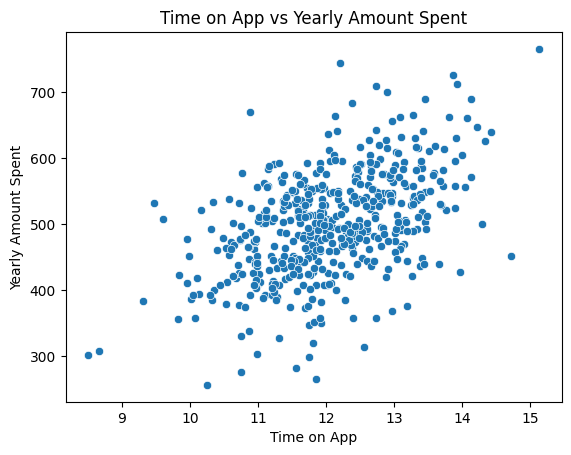

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='Time on App', y='Yearly Amount Spent', data =data)
plt.title('Time on App vs Yearly Amount Spent')
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler

features = data[['Time on App','Time on Website','Length of Membership']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [11]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,random_state=42)
kmeans.fit(scaled_features)
data['Cluster']=kmeans.labels_

In [18]:
numeric_cols = ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']

# Explicitly convert relevant columns to numeric, coercing errors to NaN
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

cluster_profile = data.groupby('Cluster')[numeric_cols].mean()
print(cluster_profile)

         Avg. Session Length  Time on App  Time on Website  \
Cluster                                                      
0                  33.037126    12.862093        37.783617   
1                  33.036838    11.447146        37.224774   
2                  33.080784    11.813577        36.279194   

         Length of Membership  Yearly Amount Spent  
Cluster                                             
0                    3.690772           539.844943  
1                    2.658227           421.166487  
2                    4.097226           525.886227  


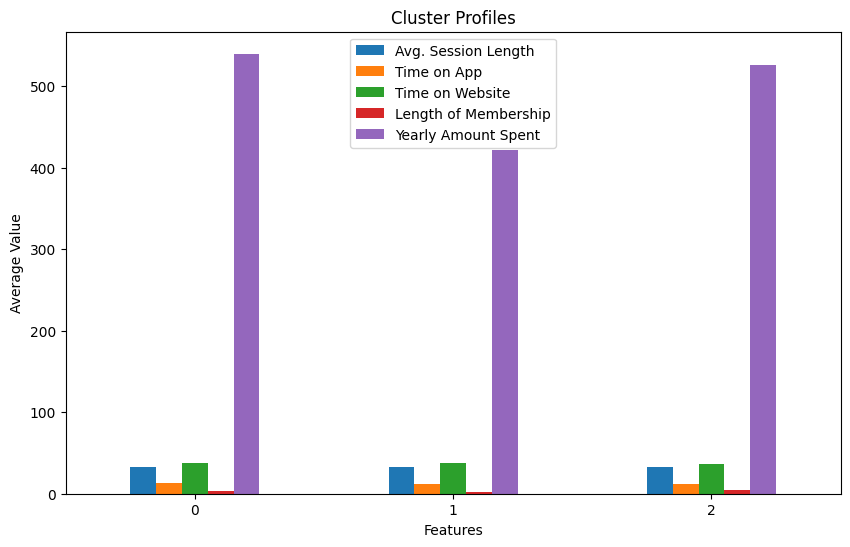

In [19]:
cluster_profile.plot(kind='bar',figsize=(10,6))
plt.title('Cluster Profiles')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.xlabel('Features')
plt.show()

In [21]:
numeric_cols = ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']
cluster_profile = data.groupby('Cluster')[numeric_cols].mean()
cluster_profile['Description'] = ['High App Engagement','Balanced Users','Low Website Time']
print(cluster_profile)

         Avg. Session Length  Time on App  Time on Website  \
Cluster                                                      
0                  33.037126    12.862093        37.783617   
1                  33.036838    11.447146        37.224774   
2                  33.080784    11.813577        36.279194   

         Length of Membership  Yearly Amount Spent          Description  
Cluster                                                                  
0                    3.690772           539.844943  High App Engagement  
1                    2.658227           421.166487       Balanced Users  
2                    4.097226           525.886227     Low Website Time  


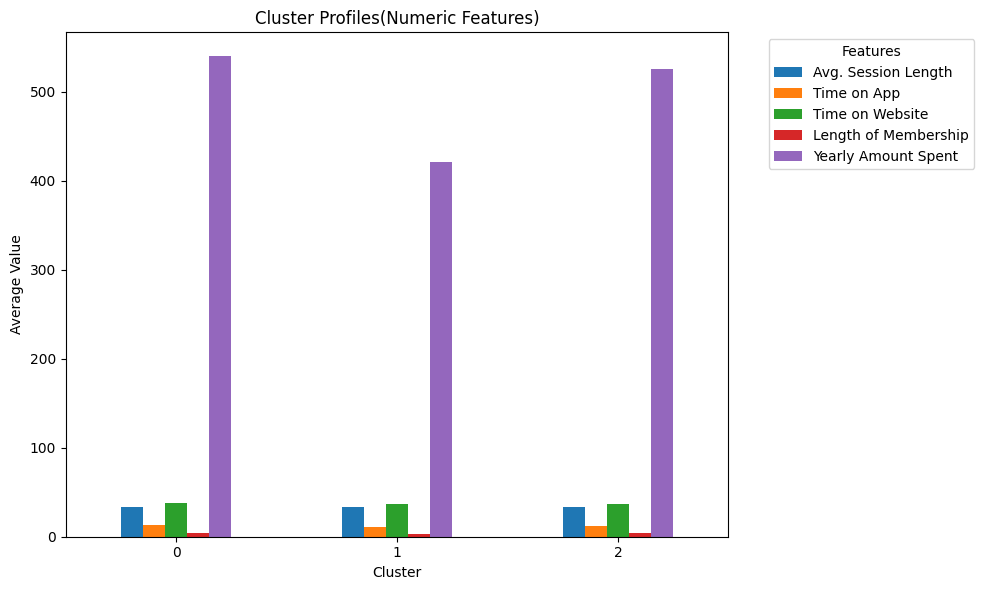

In [26]:
cluster_profile.drop('Description',axis = 1).plot(kind='bar',figsize=(10,6))
plt.title('Cluster Profiles(Numeric Features)')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(title='Features',bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.show()